<a href="https://colab.research.google.com/github/DK8832/Coding/blob/main/2026_05_19_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

텐서플로우는 구글에서 개발한 오픈소스 머신러닝 딥러닝 프레임 워크 이다.\
프레임 워크란 프로그램을 만들때 필요한 기본 툴과 도구들을 미리 만들어 둔 것이다.\
라이브러리와 프레임 워크의 차이\
라이브러리: 필요한 기능만 가져와서 쓴다\
프레임워크: 전체 구조가 이미 만들어져 있고 그 안에 내가 코드를 넣음\
딥러닝을 만들려면 행렬계산, gpu사용, 신경망 구조, 오차 계산, 역전파 알고리즘들을 전부 직접 구현해야하는데 어려움\
\
프레임 워크의 장점
1. 개발 속도가 빠름: 기본 기능이 이미 있음
2. 오류가 적음: 검증된 코드 사용 가능
3. 유지보수가 쉬움: 구조가 정해져 있음
4. 협업이 쉬움: 다른 개발자도 구조를 이해하기 쉬움\


인공지능: 구글-텐서플로우, 메타-파이토치같은 프레임워크를 사용해서 딥러닝 모델을 효율적으로 개발\

\
\
텐서플로우의 특징
1. 딥러닝에 강함: 신경망을 쉽게  만들 수 있음
2. GPU사용 가능: CPU보다 훨씬 빠르게 학습할 수 있도록 GPU가속을 지원(데이터가 많을 때 학습속도 차이가 큼)
3. KERAS가 포함되어 있음: KERAS라는 고수준 api가 들어있어 복잡한 딥러닝 모델도 비교적 짧은 코드로 만들 수 있음\

\
기본 흐름: 데이버 준비 -> 모델 생성 -> 모델 학습 -> 결과 예측 -> 성능 평가
\
\
많이 사용되는 분야
1. 이미지 분류
2. 얼굴 인식
3. 음성 인식
4. 자연어 처리(번역등)
5. 객체 탐지
6. 예측 모델 제작(주가, 날씨, 판매량등)


In [19]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input        # type:ignore
#mobilenet_v2: 모델에 넣기 전에 모델이 학습했던 형태로 변환하는 함수
from tensorflow.keras.models import load_model #type:ignore
#저장된 인공지능 모델 파일을 불러오는 함수


In [20]:
facenet = cv2.dnn.readNet(
    '/content/drive/MyDrive/Colab Notebooks/etc/deploy.prototxt',
    '/content/drive/MyDrive/Colab Notebooks/etc/res10_300x300_ssd_iter_140000.caffemodel'
)
#prototxt: 설계도
#caffemodel: 학습된 가중치(학습해서 얻은 지식(기억))
#마스크 착용 여부를 분류 할 수 있도록 학습된 모델 불러오기
model = load_model('/content/drive/MyDrive/Colab Notebooks/etc/mask_detector.h5')

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


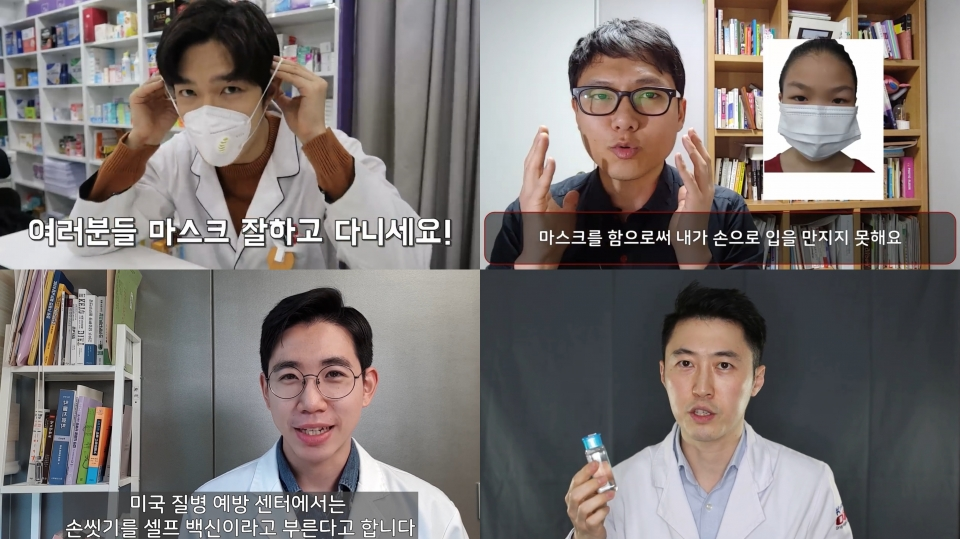

In [21]:
img = cv2.imread('/content/drive/MyDrive/Colab Notebooks/image/mask3.jpg')
cv2_imshow(img)

In [22]:
blob = cv2.dnn.blobFromImage(img, mean=(104, 177, 123))

In [23]:
facenet.setInput(blob)
dets = facenet.forward() # 얼굴 영역 탐지 결과 저장

In [24]:
print(dets.shape)
#이미지개수, 의미없음(형식 맞추기), 얼굴개수, 정보 개수

(1, 1, 200, 7)


In [25]:
h, w, c = img.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


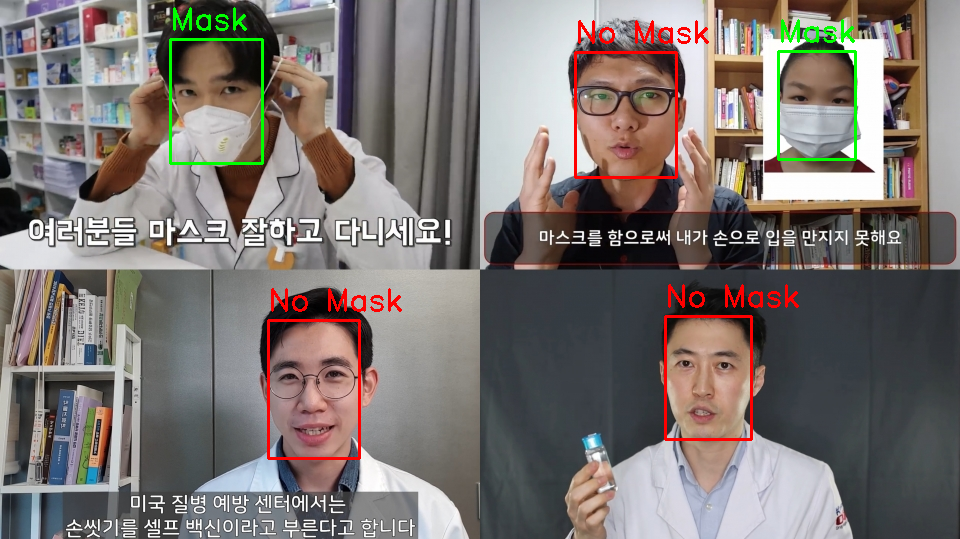

In [36]:
for i in range(dets.shape[2]):
  confidence = dets[0, 0, i, 2]
  if confidence < 0.5:
    continue
  x1 = int(dets[0, 0, i, 3]*w)
  y1 = int(dets[0, 0, i, 4]*h)
  x2 = int(dets[0, 0, i, 5]*w)
  y2 = int(dets[0, 0, i, 6]*h)
  face = img[y1:y2, x1:x2]
  face_input = cv2.resize(face, dsize=(224, 224))
  face_input = cv2.cvtColor(face_input, cv2.COLOR_BGR2RGB)
  face_input = preprocess_input(face_input)
  face_input = np.expand_dims(face_input, axis=0)
  mask, nomask = model.predict(face_input).squeeze()
  if mask > nomask:
    color = (0, 255, 0)
    label = 'Mask'
  else:
    color = (0, 0, 255)
    label = 'No Mask'

  cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
  cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
cv2_imshow(img)
